# Chapter 6. 차원의 축소



In [1]:
import nltk
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('webtext')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets_json')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package webtext to /root/nltk_data...
[nltk_data]   Unzipping corpora/webtext.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagge

True

## 4.PCA를 통한 군집화

In [2]:
from sklearn.datasets import fetch_20newsgroups

# 무신론, 종교, 컴퓨터 그래픽스, 우주 과학
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']

newsgroups_train = fetch_20newsgroups(subset='train',
                                      remove=('headers', 'footers', 'quotes'),
                                      categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test',
                                     remove=('headers', 'footers', 'quotes'),
                                     categories=categories)

X_train = newsgroups_train.data
y_train = newsgroups_train.target

X_test = newsgroups_test.data
y_test = newsgroups_test.target

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords
cachedStopWords = stopwords.words("english")

from nltk.tokenize import RegexpTokenizer
from nltk.stem.porter import PorterStemmer

RegTok = RegexpTokenizer(r"[\w']{3,}") # 정규포현식으로 토크나이저를 정의
english_stops = set(stopwords.words('english')) #영어 불용어를 가져옴

def tokenizer(text):
    tokens = RegTok.tokenize(text.lower())
    words = [word for word in tokens if (word not in english_stops) and len(word) > 2]
    features = (list(map(lambda token: PorterStemmer().stem(token),words)))
    return features

tfidf = TfidfVectorizer(tokenizer=tokenizer)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(2034, 20068)
(1353, 20068)


In [3]:
from sklearn.datasets import fetch_20newsgroups

# 무신론, 종교, 컴퓨터 그래픽스, 우주 과학
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']

newsgroups_train = fetch_20newsgroups(subset='train',
                                      remove=('headers', 'footers', 'quotes'),
                                      categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test',
                                     remove=('headers', 'footers', 'quotes'),
                                     categories=categories)

X_train = newsgroups_train.data
y_train = newsgroups_train.target

X_test = newsgroups_test.data
y_test = newsgroups_test.target

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords
cachedStopWords = stopwords.words("english")

from nltk.tokenize import RegexpTokenizer
from nltk.stem.porter import PorterStemmer

RegTok = RegexpTokenizer(r"[\w']{3,}") # 정규포현식으로 토크나이저를 정의
english_stops = set(stopwords.words('english')) #영어 불용어를 가져옴

def tokenizer(text):
    tokens = RegTok.tokenize(text.lower())
    words = [word for word in tokens if (word not in english_stops) and len(word) > 2]
    features = (list(map(lambda token: PorterStemmer().stem(token),words)))
    return features

tfidf = TfidfVectorizer(tokenizer=tokenizer)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(2034, 20068)
(1353, 20068)


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2000, random_state=7)
X_train_pca = pca.fit_transform(X_train_tfidf.toarray())
X_test_pca = pca.transform(X_test_tfidf.toarray())

print('Original tfidf matrix shape:', X_train_tfidf.shape)
print('PCA Converted matrix shape:', X_train_pca.shape)
print('Sum of explained variance ratio: {:.3f}'.format(pca.explained_variance_ratio_.sum()))


Original tfidf matrix shape: (2034, 20068)
PCA Converted matrix shape: (2034, 2000)
Sum of explained variance ratio: 1.000


### 4.1 K-means

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

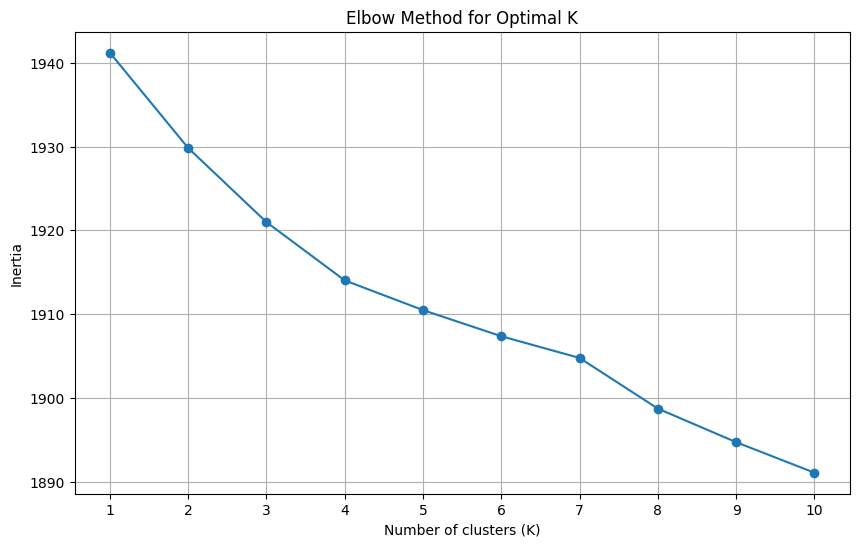

In [6]:
kmeans = KMeans(n_clusters=4, random_state=7, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_train_pca)


inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=7, n_init='auto')
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()



- tfidf

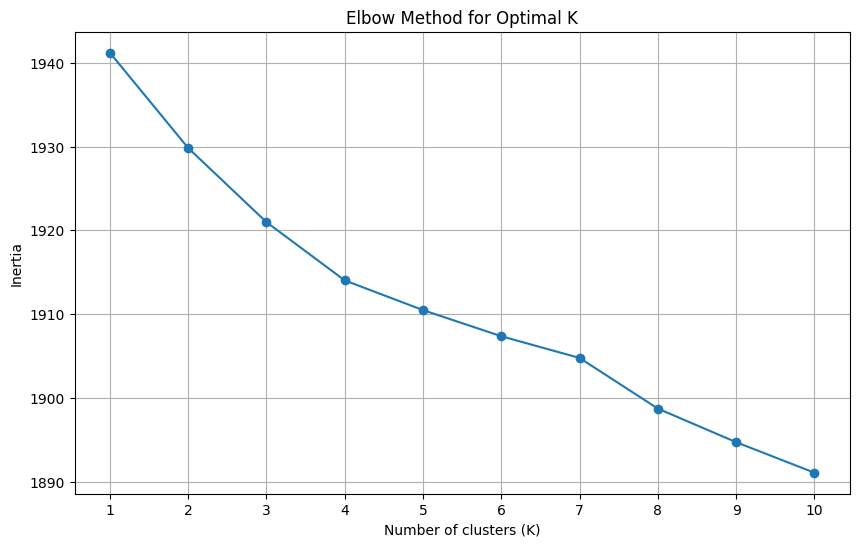

In [7]:
kmeans = KMeans(n_clusters=4, random_state=7, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_train_tfidf)

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=7, n_init='auto')
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()



- 실루엣 값

For n_clusters = 2, shadow score is 0.0098
For n_clusters = 3, shadow score is 0.0086
For n_clusters = 4, shadow score is 0.0075
For n_clusters = 5, shadow score is 0.0073
For n_clusters = 6, shadow score is 0.0025
For n_clusters = 7, shadow score is 0.0005
For n_clusters = 8, shadow score is 0.0035
For n_clusters = 9, shadow score is 0.0026
For n_clusters = 10, shadow score is 0.0036


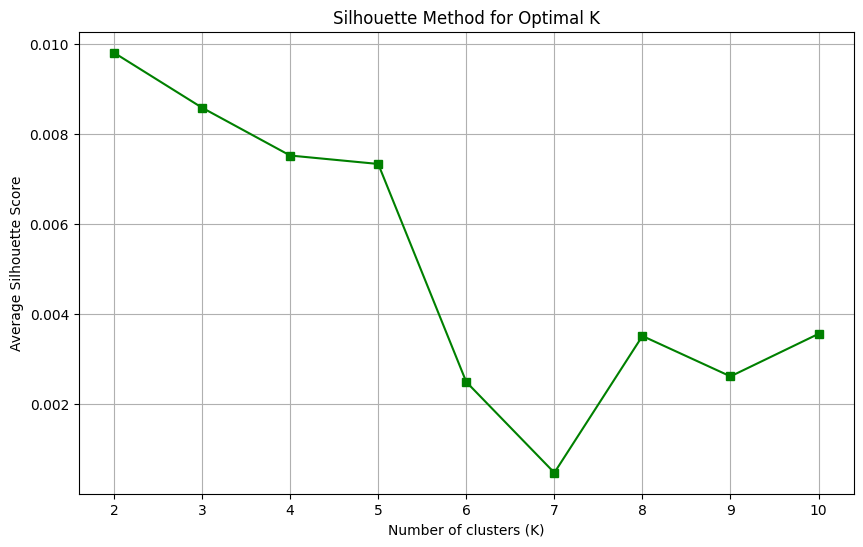

In [8]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_avg = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=7, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_train_pca)

    score = silhouette_score(X_train_pca, cluster_labels)
    silhouette_avg.append(score)
    print(f"For n_clusters = {k}, shadow score is {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_avg, marker='s', color='green')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

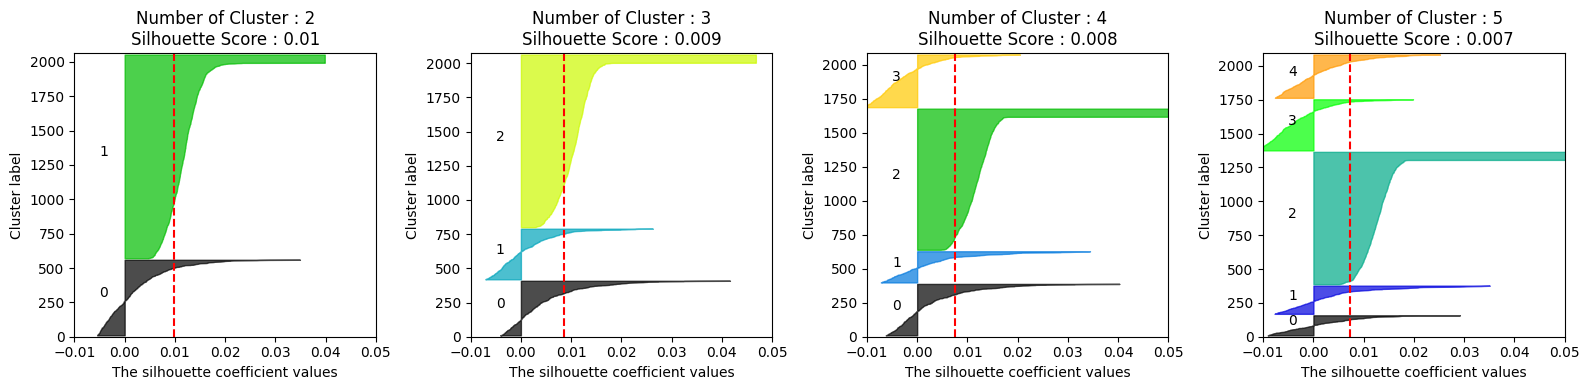

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

def visualize_silhouette_zoom(cluster_lists, X_features):
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    for ind, n_cluster in enumerate(cluster_lists):
        clusterer = KMeans(n_clusters=n_cluster, random_state=7, n_init='auto')
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster) + '\n' \
                          'Silhouette Score : ' + str(round(sil_avg, 3)))
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")

        axs[ind].set_xlim([-0.01, 0.05])

        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])

        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.005, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

visualize_silhouette_zoom([2, 3, 4, 5], X_train_pca)
plt.tight_layout()
plt.show()


#.

In [10]:

N_CLUSTER = 4
kmeans = KMeans(n_clusters=N_CLUSTER, random_state=7, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_train_pca)

In [11]:
import pandas as pd
import numpy as np

unique_elements, counts_elements = np.unique(newsgroups_train.target, return_counts=True)
actual_counts = dict(zip(newsgroups_train.target_names, counts_elements))

cluster_labels, cluster_counts = np.unique(kmeans_labels, return_counts=True)
predicted_counts = dict(zip([f"Cluster {i}" for i in cluster_labels], cluster_counts))

print(" [1. 실제 카테고리별 데이터 개수 (정답)] ")
df_actual = pd.DataFrame(list(actual_counts.items()), columns=['Category', 'Count'])
print(df_actual)

print("\n [2. 모델이 분류한 군집별 데이터 개수 (예측)] ")
df_predicted = pd.DataFrame(list(predicted_counts.items()), columns=['Cluster', 'Count'])
print(df_predicted)

print(f"\n총 데이터 개수: {sum(counts_elements)}개 (정답) == {sum(cluster_counts)}개 (예측)")



 [1. 실제 카테고리별 데이터 개수 (정답)] 
             Category  Count
0         alt.atheism    480
1       comp.graphics    584
2           sci.space    593
3  talk.religion.misc    377

 [2. 모델이 분류한 군집별 데이터 개수 (예측)] 
     Cluster  Count
0  Cluster 0    379
1  Cluster 1    230
2  Cluster 2   1038
3  Cluster 3    387

총 데이터 개수: 2034개 (정답) == 2034개 (예측)


##### 성능지표

In [12]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

actual_labels = newsgroups_train.target
category_names = newsgroups_train.target_names
kmeans_labels = kmeans.labels_ # 이미 학습된 kmeans 모델의 라벨 사용

comparison_df = pd.DataFrame({
    'Actual_Category': [category_names[i] for i in actual_labels],
    'Cluster': kmeans_labels
})

results_ct = pd.crosstab(comparison_df['Actual_Category'], comparison_df['Cluster'])

print(" [실제 정답 vs 군집 결과 교차표] ")
display(results_ct)

ari = adjusted_rand_score(actual_labels, kmeans_labels)
nmi = normalized_mutual_info_score(actual_labels, kmeans_labels)

print(f"\n--- 성능 평가 지표 ---")
print(f"ARI (Adjusted Rand Index): {ari:.4f}")
print(f"NMI (Normalized Mutual Information): {nmi:.4f}")

 [실제 정답 vs 군집 결과 교차표] 


Cluster,0,1,2,3
Actual_Category,,,,
alt.atheism,221,1,256,2
comp.graphics,0,6,212,366
sci.space,1,223,353,16
talk.religion.misc,157,0,217,3



--- 성능 평가 지표 ---
ARI (Adjusted Rand Index): 0.1962
NMI (Normalized Mutual Information): 0.3716


In [13]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=7)
tsne_results = tsne.fit_transform(X_train_pca)



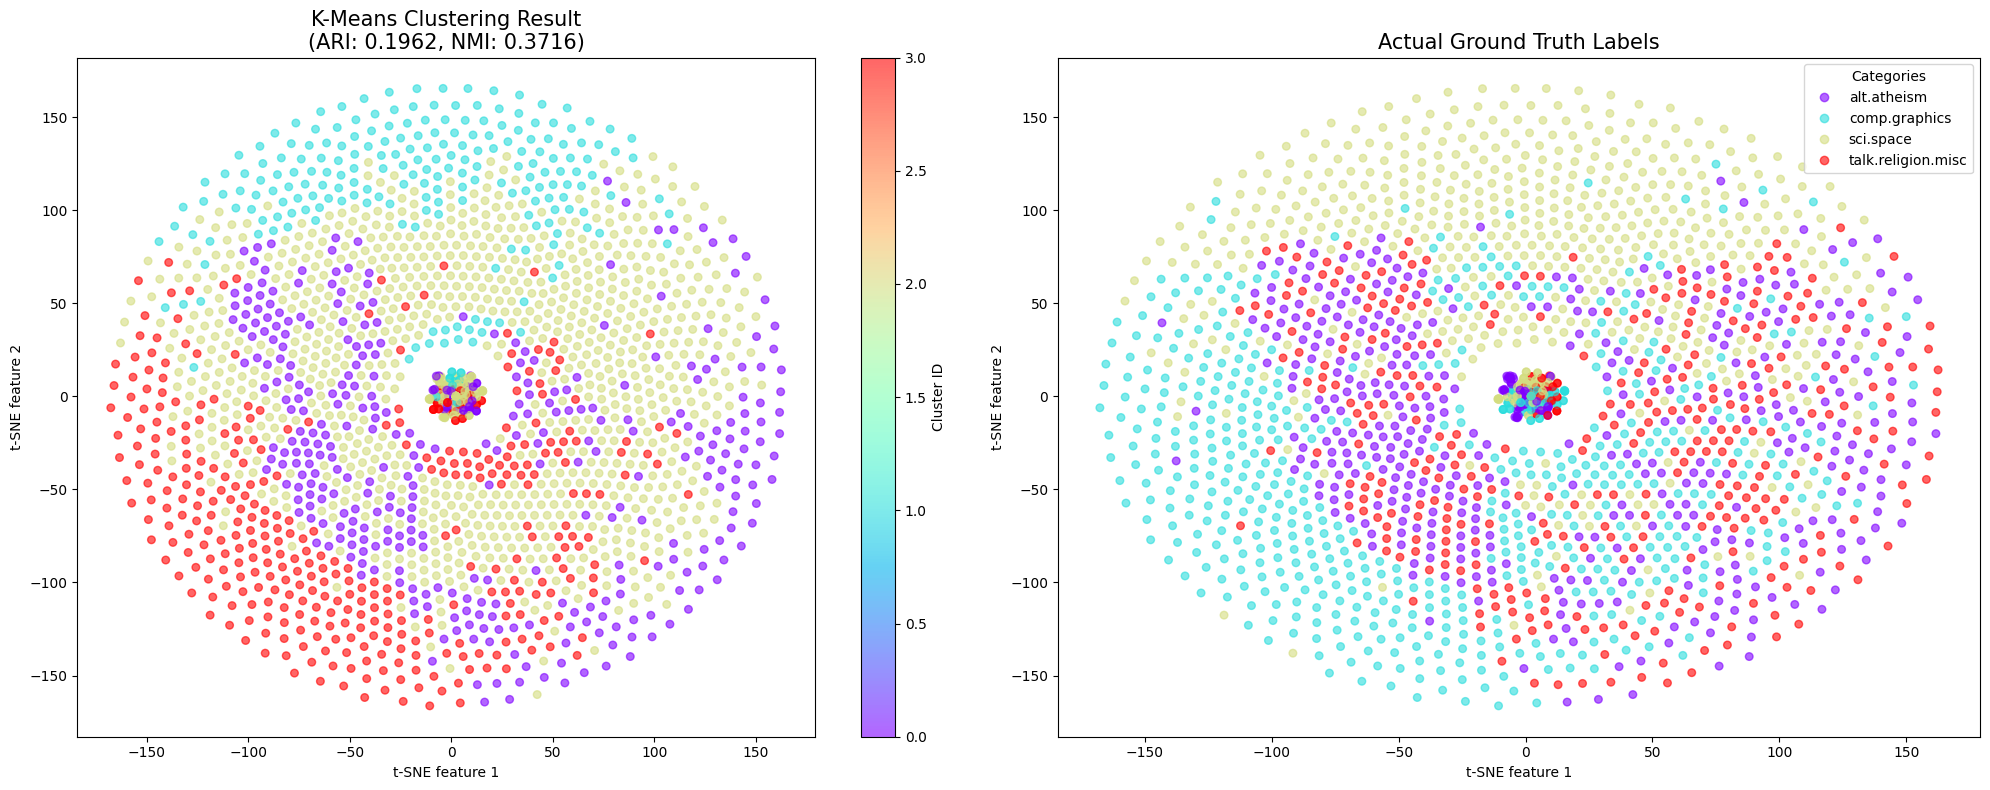

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(figsize=(20, 8), nrows=1, ncols=2)

scatter1 = ax1.scatter(tsne_results[:, 0], tsne_results[:, 1],
                       c=kmeans_labels, cmap='rainbow', s=30, alpha=0.6)
ax1.set_title(f'K-Means Clustering Result\n(ARI: {ari:.4f}, NMI: {nmi:.4f})', fontsize=15)
ax1.set_xlabel('t-SNE feature 1')
ax1.set_ylabel('t-SNE feature 2')
plt.colorbar(scatter1, ax=ax1, label='Cluster ID')

scatter2 = ax2.scatter(tsne_results[:, 0], tsne_results[:, 1],
                       c=newsgroups_train.target, cmap='rainbow', s=30, alpha=0.6)
ax2.set_title('Actual Ground Truth Labels', fontsize=15)
ax2.set_xlabel('t-SNE feature 1')
ax2.set_ylabel('t-SNE feature 2')

handles, labels = scatter2.legend_elements()
ax2.legend(handles, newsgroups_train.target_names, loc="upper right", title="Categories")

plt.tight_layout()
plt.show()

### 4.2. 위계적 군집화 및 덴드로그램

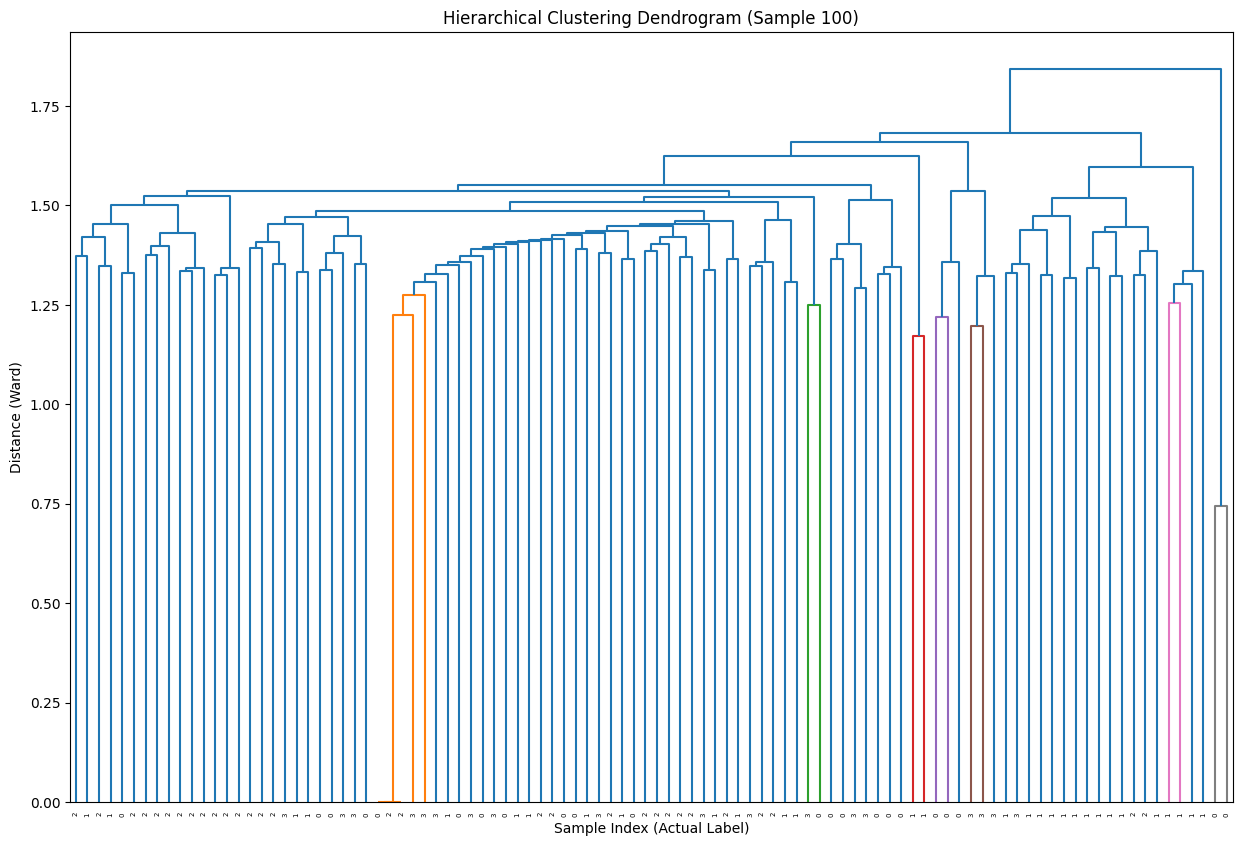

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

data_sample = X_train_pca[:100]
sample_labels = y_train[:100] # 실제 정답 라벨 (비교용)


linked = linkage(data_sample, method='ward')

plt.figure(figsize=(15, 10))
dendrogram(linked,
           orientation='top',
           labels=sample_labels,
           distance_sort='descending',
           show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (Sample 100)')
plt.xlabel('Sample Index (Actual Label)')
plt.ylabel('Distance (Ward)')
plt.show()

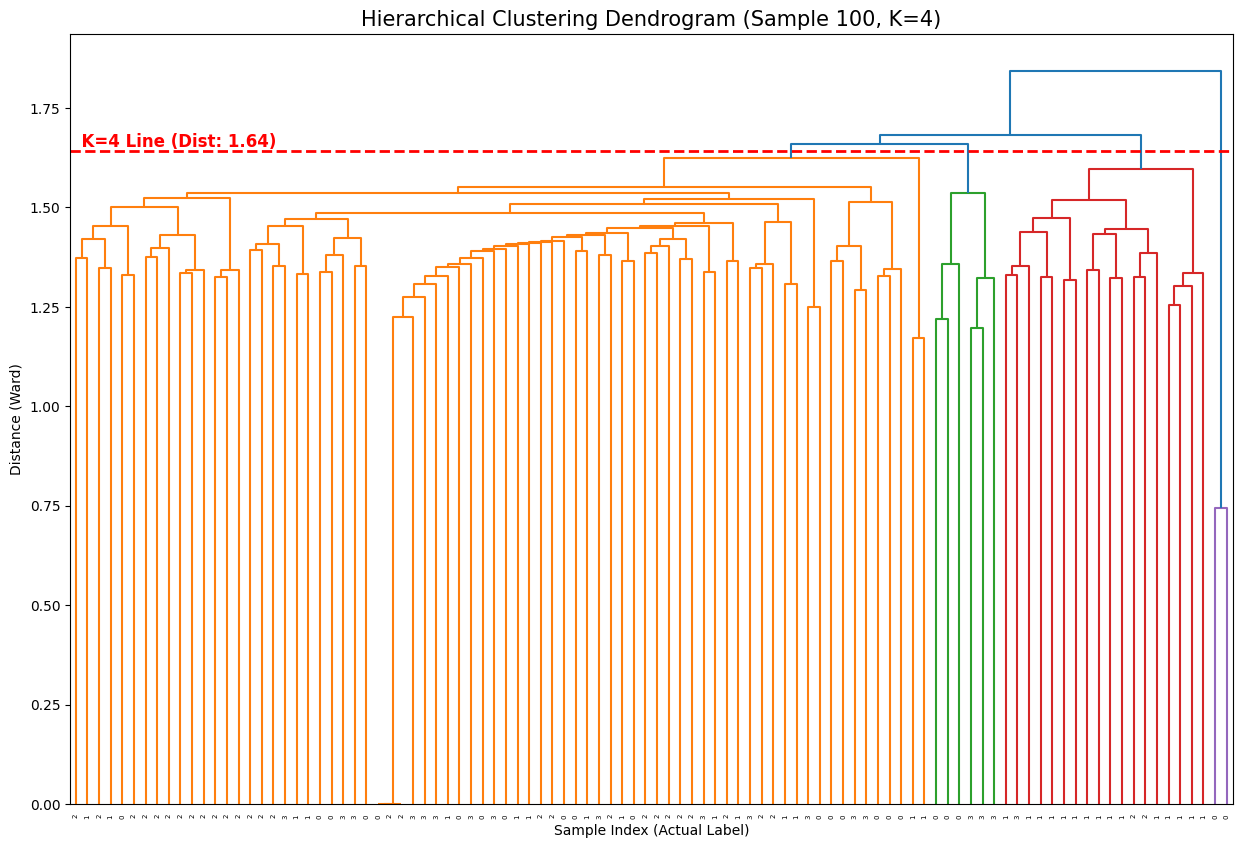

In [16]:

threshold = (linked[-3, 2] + linked[-4, 2]) / 2

plt.figure(figsize=(15, 10))


dendrogram(linked,
           orientation='top',
           labels=sample_labels,
           distance_sort='descending',
           color_threshold=threshold,
           show_leaf_counts=True)

plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2)
plt.text(0, threshold, f'  K=4 Line (Dist: {threshold:.2f})',
         va='bottom', ha='left', fontsize=12, color='red', fontweight='bold')

plt.title('Hierarchical Clustering Dendrogram (Sample 100, K=4)', fontsize=15)
plt.xlabel('Sample Index (Actual Label)')
plt.ylabel('Distance (Ward)')
plt.show()

##### 성능지표

In [17]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd


Z = linkage(X_train_pca, method='ward')

hier_labels = fcluster(Z, t=4, criterion='maxclust')

ari_hier = adjusted_rand_score(actual_labels, hier_labels)
nmi_hier = normalized_mutual_info_score(actual_labels, hier_labels)

print(" [계층적 군집화 (Ward) 성능 결과] ")
print(f"ARI (Adjusted Rand Index): {ari_hier:.4f}")
print(f"NMI (Normalized Mutual Information): {nmi_hier:.4f}")

unique, counts = np.unique(hier_labels, return_counts=True)
print("\n [군집별 데이터 개수]")
print(dict(zip([f"Cluster {i}" for i in unique], counts)))

 [계층적 군집화 (Ward) 성능 결과] 
ARI (Adjusted Rand Index): 0.1711
NMI (Normalized Mutual Information): 0.2644

 [군집별 데이터 개수]
{'Cluster 1': np.int64(483), 'Cluster 2': np.int64(15), 'Cluster 3': np.int64(1371), 'Cluster 4': np.int64(165)}


### 4.3.DBSCAN(밀도 기반 군집 분석)
- 하이퍼파라미터: 엠실론, 최소 관측치 수

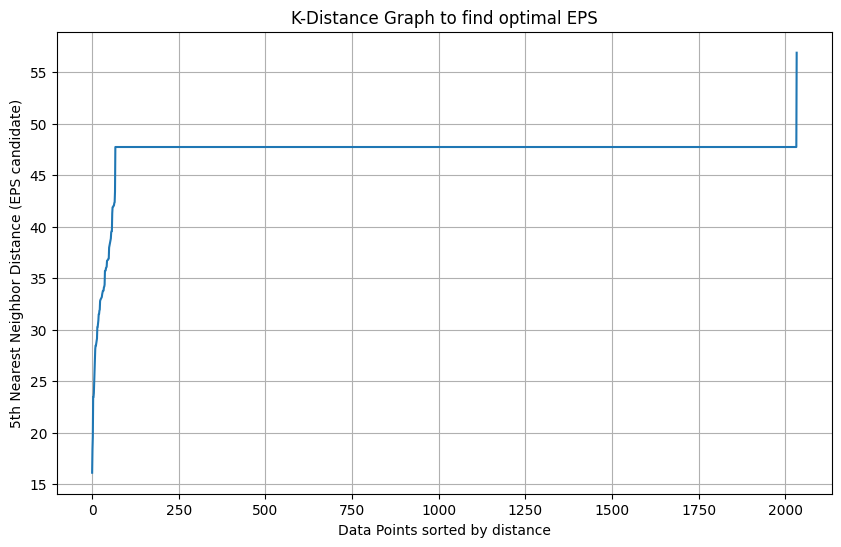

In [18]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_pca)

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph to find optimal EPS')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance (EPS candidate)')
plt.grid(True)
plt.show()



In [19]:

for e in [30.0, 35.0, 40.0, 45.0]:
    dbscan = DBSCAN(eps=e, min_samples=2)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    ari = adjusted_rand_score(y_train, labels)

    print(f"eps: {e} -> 군집 수: {n_clusters}, 노이즈: {n_noise}, ARI: {ari:.4f}")

eps: 30.0 -> 군집 수: 1, 노이즈: 2009, ARI: -0.0001
eps: 35.0 -> 군집 수: 1, 노이즈: 1987, ARI: 0.0010
eps: 40.0 -> 군집 수: 1, 노이즈: 1973, ARI: 0.0011
eps: 45.0 -> 군집 수: 1, 노이즈: 1967, ARI: 0.0010


In [20]:
EPS = 35
MIN_SAMPLES=2
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)


dbscan_labels = dbscan.fit_predict(X_scaled)

print(f"DBSCAN 학습 완료! (사용한 eps: {EPS}, min_samples: {MIN_SAMPLES})")

DBSCAN 학습 완료! (사용한 eps: 35, min_samples: 2)


#### 성능지표

In [21]:



EPS = 32
dbscan = DBSCAN(eps=EPS, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)


import numpy as np
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f'추정된 군집 개수: {n_clusters_}')
print(f'노이즈 포인트 개수: {n_noise_}')

ari_dbscan = adjusted_rand_score(y_train, dbscan_labels)
print(f"DBSCAN ARI 점수: {ari_dbscan:.4f}")

추정된 군집 개수: 1
노이즈 포인트 개수: 2000
DBSCAN ARI 점수: 0.0006


t-SNE 기반 DBSCAN -> 군집 수: 6, 노이즈: 1943, ARI: 0.0015


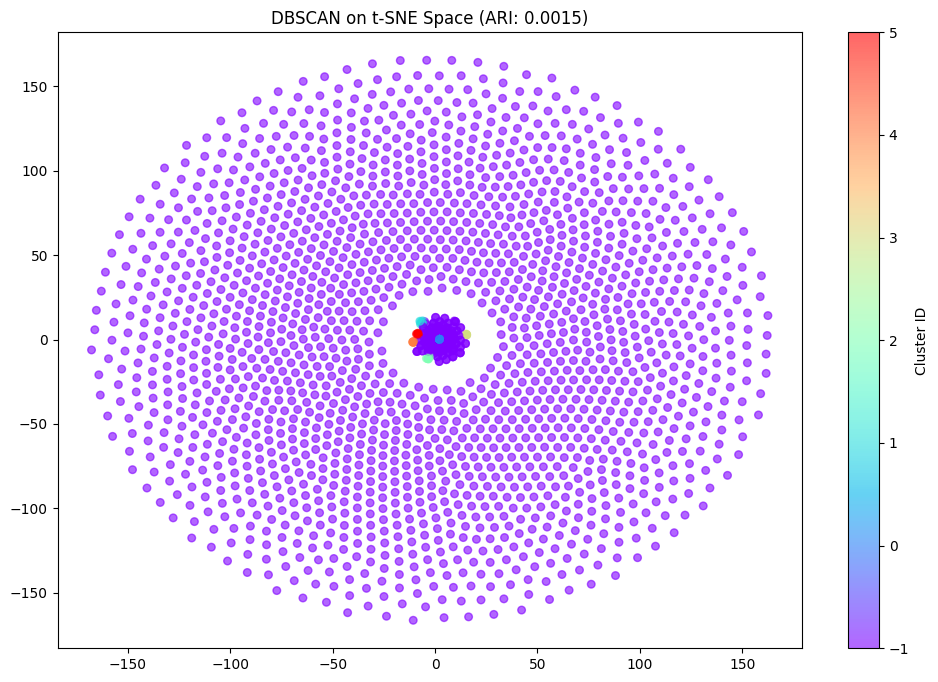

In [22]:

from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt


dbscan_tsne = DBSCAN(eps=1.0, min_samples=5)
tsne_labels = dbscan_tsne.fit_predict(tsne_results)

n_clusters = len(set(tsne_labels)) - (1 if -1 in tsne_labels else 0)
n_noise = list(tsne_labels).count(-1)
ari_tsne = adjusted_rand_score(y_train, tsne_labels)

print(f"t-SNE 기반 DBSCAN -> 군집 수: {n_clusters}, 노이즈: {n_noise}, ARI: {ari_tsne:.4f}")

plt.figure(figsize=(12, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=tsne_labels, cmap='rainbow', s=30, alpha=0.6)
plt.title(f'DBSCAN on t-SNE Space (ARI: {ari_tsne:.4f})')
plt.colorbar(label='Cluster ID')
plt.show()

### 4.3. 가우시안 혼합 모델(GMM)

In [23]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

gmm = GaussianMixture(n_components=4, random_state=7, covariance_type='full')
gmm_labels = gmm.fit_predict(X_train_pca)


##### 성능지표

In [24]:
ari_gmm = adjusted_rand_score(y_train, gmm_labels)
nmi_gmm = normalized_mutual_info_score(y_train, gmm_labels)

print(f" [GMM(K=4) 성능 지표] ")
print(f"ARI (Adjusted Rand Index): {ari_gmm:.4f}")
print(f"NMI (Normalized Mutual Information): {nmi_gmm:.4f}")

 [GMM(K=4) 성능 지표] 
ARI (Adjusted Rand Index): 0.1962
NMI (Normalized Mutual Information): 0.3716


In [25]:
import pandas as pd
import numpy as np

all_probs = gmm.predict_proba(X_train_pca)
prob_cols = [f'Cluster {i}' for i in range(4)]
df_probs = pd.DataFrame(all_probs * 100, columns=prob_cols).round(2)


sorted_probs = np.sort(all_probs, axis=1)
margin = sorted_probs[:, -1] - sorted_probs[:, -2]
df_probs['Margin'] = margin


confident_samples = df_probs[df_probs['Margin'] > 0.99].head(3)


confused_samples = df_probs.sort_values(by='Margin').head(3)

print(" [Case A: 모델이 99% 이상 확신하는 데이터] ")
print(confident_samples[prob_cols])

print("\n" + "="*60)
print(" [Case B: 모델이 고민하는 데이터] ")
print(confused_samples[prob_cols])


 [Case A: 모델이 99% 이상 확신하는 데이터] 
   Cluster 0  Cluster 1  Cluster 2  Cluster 3
0        0.0        0.0        0.0      100.0
1        0.0        0.0      100.0        0.0
2        0.0        0.0      100.0        0.0

 [Case B: 모델이 고민하는 데이터] 
      Cluster 0  Cluster 1  Cluster 2  Cluster 3
2031        0.0        0.0        0.0      100.0
2030        0.0        0.0      100.0        0.0
2029        0.0        0.0        0.0      100.0


In [26]:
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


pca_low = PCA(n_components=50, random_state=7)
X_train_pca_low = pca_low.fit_transform(X_train_tfidf.toarray())

gmm = GaussianMixture(n_components=4, random_state=7, covariance_type='full')
gmm.fit(X_train_pca_low)

all_probs = gmm.predict_proba(X_train_pca_low)
df_probs_new = pd.DataFrame(all_probs * 100, columns=[f'Cluster {i}' for i in range(4)]).round(2)

margin_new = np.sort(all_probs, axis=1)[:, -1] - np.sort(all_probs, axis=1)[:, -2]
df_probs_new['Margin'] = margin_new

confused_samples = df_probs_new.sort_values(by='Margin').head(5)
print(" [50차원 축소 후] ")
print(confused_samples[[f'Cluster {i}' for i in range(4)]])

 [50차원 축소 후] 
      Cluster 0  Cluster 1  Cluster 2  Cluster 3
275         0.0      46.14      53.86       0.00
1111        0.0      59.41      40.59       0.00
1524        0.0      77.05      22.95       0.00
295         0.0      21.74       0.00      78.26
1095        0.0      75.35      14.56      10.09
